# Testing the draft 2D density / contour plot (`new_graphics/density2d.py`)

This notebook exercises `make_density2D()`, the draft implementation of the new 2D
continuous-x-continuous plot type. It is **not** wired into `.plot()` yet — this is
for visually checking the draft before integration.

`make_density2D` renders a KDE density surface, and `contour=` chooses the look:
- `contour=False` (default): a **continuous** density plot -- a smooth color
  gradient with no visible bands -- the "2D Density Plot" look
- `contour=True`: a **topographic contour plot** -- the same surface split into
  discrete color bands with thin white outlines between them

`levels=` sets how many discrete bands the contour plot uses (default
`DENSITY2D_LEVELS = 8`, a first guess the team will revisit). It **only applies when
`contour=True`** -- the continuous density plot has no bands, so passing `levels=`
without `contour=True` warns and is ignored.

**How to run:** open this notebook using the `symbulate` conda environment (kernel
"Python (symbulate)"), then Run All. The setup cell locates the repo root itself (by
walking up from the working directory) so it works regardless of where Jupyter's cwd lands.

**What to look for in every plot:**
- Viridis colormap, dark purple (low density) to yellow (high density)
- Default (`contour=False`): a smooth continuous gradient with no countable bands
- `contour=True`: discrete color bands (8 by default) countable against the
  colorbar segments (`levels=` changes the count)
- Colorbar on the right, labeled "Density" in both modes -- `contour=True` only
  changes the *rendering*, not the underlying statistic
- In contour mode, colorbar tick labels are rounded automatically -- just enough
  decimal places to tell adjacent band edges apart, not raw unrounded values
- Quantile-based axis limits (0.1st–99.9th percentile + padding), not raw min/max
- `contour=True` differs from `contour=False` by the discrete bands and thin white outlines


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Locate the repo root (the folder containing symbulate/symbulate.mplstyle) by
# walking up from the working directory, so this notebook runs the same way
# regardless of where Jupyter's cwd lands.
_here = Path.cwd()
REPO_ROOT = next(
    p for p in [_here, *_here.parents]
    if (p / "symbulate" / "symbulate.mplstyle").exists()
)
sys.path.insert(0, str(REPO_ROOT / "team" / "new_graphics"))

# The draft helper and its per-plot-type constants
from density2d import (
    make_density2D,
    DENSITY2D_GRID_POINTS,
    DENSITY2D_LEVELS,
)

# Apply the global style file (Okabe-Ito cycle, grid, spines, fonts).
# Not yet wired into the package, so we apply it by hand here.
STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)
print(f"DENSITY2D_GRID_POINTS = {DENSITY2D_GRID_POINTS}, "
      f"DENSITY2D_LEVELS = {DENSITY2D_LEVELS}")

DENSITY2D_GRID_POINTS = 300, DENSITY2D_LEVELS = 8


## 1. The two looks: continuous density vs. contour

Correlated bivariate normal data (x, and y = 0.7x + noise), so the surface is
diagonally elongated like the reference images. Both plots use the *same* simulated
data and the same underlying KDE surface -- only `contour=` differs. The default
(`contour=False`) shades it as a smooth continuous gradient; `contour=True` splits it
into 8 discrete bands with thin white outlines so they can be read off the colorbar.


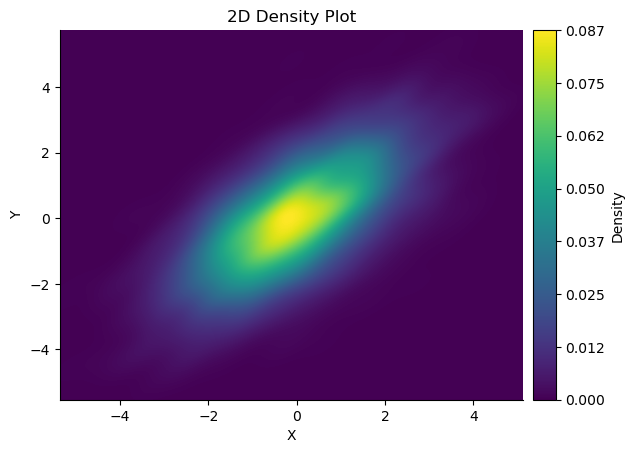

In [3]:
x = rng.normal(0, 1.5, 3000)
y = 0.7 * x + rng.normal(0, 1.2, 3000)

ax = plt.gca()
make_density2D(x, y, ax)  # contour=False (default): continuous "2D Density Plot"
plt.show()

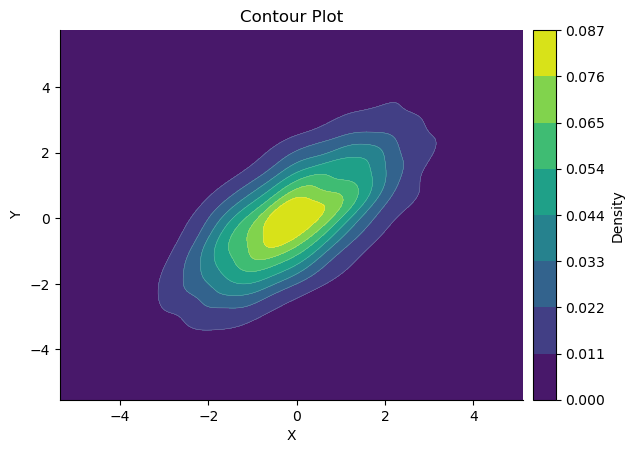

In [4]:
plt.figure()
ax = plt.gca()
make_density2D(x, y, ax, contour=True)  # banded "Contour Plot"
plt.show()

## 2. Choosing the number of color bands (`levels=`, contour mode only)

`levels=` sets how many discrete color bands the **contour plot** is split into, so
it only takes effect together with `contour=True`. The default of 8 is a first guess
-- this section draws the same data at `contour=True, levels=16` so the team can
compare candidate defaults side by side. A value that isn't a whole number of at
least 2 raises a student-friendly error (in contour mode). Passing `levels=` without
`contour=True` is shown next: it warns and is ignored, since the continuous density
plot has no bands.

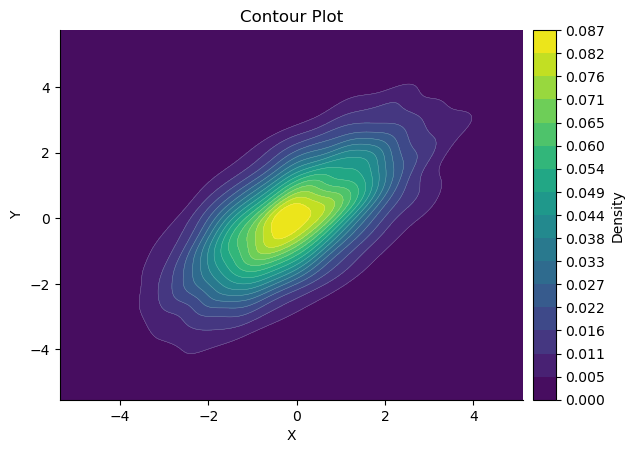

In [6]:
plt.figure()
ax = plt.gca()
make_density2D(x, y, ax, contour=True, levels=16)  # same data as Section 1, twice the bands
plt.show()

In [10]:
plt.figure()
try:
    make_density2D(x, y, plt.gca(), contour=True, levels=1)
except ValueError as e:
    print(f"ValueError: {e}")
plt.close("all")  # nothing was drawn; discard the empty figure

ValueError: levels must be a whole number of at least 2 -- it sets how many discrete color bands the contour plot is split into. You passed levels=1. Try levels=8 (the default).


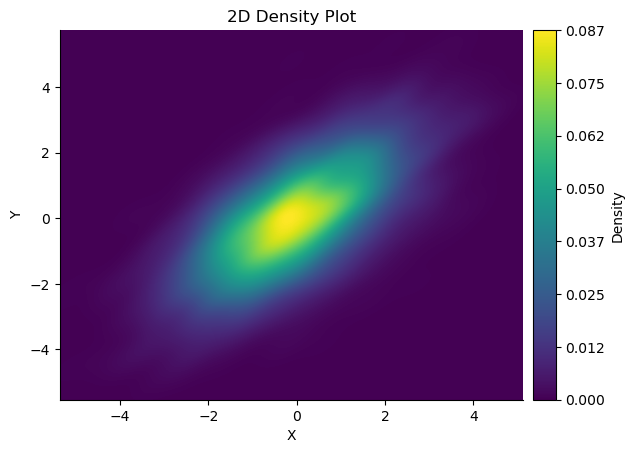

In [11]:
import warnings

# levels only applies in contour mode. Passing it to the continuous density
# plot (contour=False) warns and is ignored -- the surface stays continuous.
plt.figure()
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    make_density2D(x, y, plt.gca(), levels=16)  # no contour=True
for w in caught:
    print(f"{w.category.__name__}: {w.message}")
plt.show()

## 3. Reasonable axis limits on outlier-heavy data

Same idea as the 1D density curve: quantile-based bounds instead of raw min/max, so
a heavy-tailed variable (Exponential here, paired with a Normal) doesn't stretch the
plot. The printed comparison shows how much narrower the quantile-based x-range is.

raw x min/max range:     [0.00, 9.65]  (width 9.65)
quantile-based x-range:   [-0.69, 7.62]  (width 8.31)


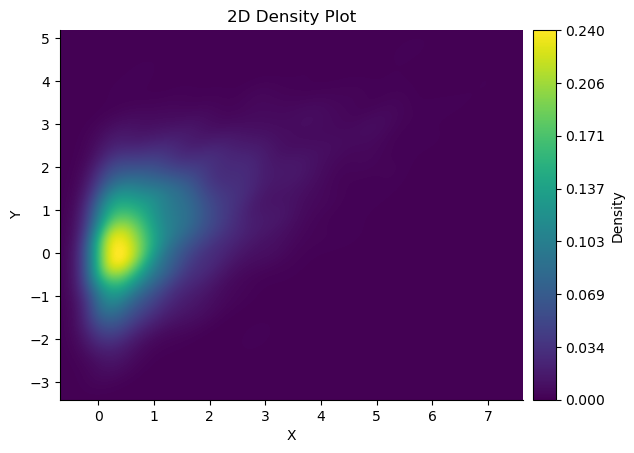

In [12]:
x_exp = rng.exponential(1, 3000)
y_normal = 0.5 * x_exp + rng.normal(0, 1, 3000)

print(f"raw x min/max range:     [{x_exp.min():.2f}, {x_exp.max():.2f}]  "
      f"(width {x_exp.max() - x_exp.min():.2f})")

ax = plt.gca()
make_density2D(x_exp, y_normal, ax)
qxmin, qxmax = ax.get_xlim()
print(f"quantile-based x-range:   [{qxmin:.2f}, {qxmax:.2f}]  (width {qxmax - qxmin:.2f})")
plt.show()

## 4. Overlay behavior — readability warning, not a silent stack

A filled 2D surface can't overlay naturally the way a 1D curve or histogram can: a
second call completely covers the first, and the two color scales compete for the
same colorbar. Rather than silently producing a misleading plot, a second call on the
same axes should print a readability warning below and still draw (matching the
existing warning-category behavior for two 2D tile or two 2D histogram plots).

Showing a second 2D density plot on the same axes. The two color scales compete and this plot now covers up the first one. Try two separate plots (e.g. subplots) instead.


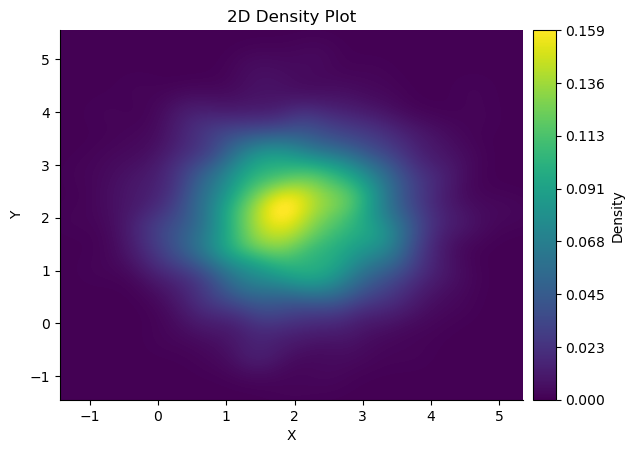

In [13]:
sample_a_x = rng.normal(0, 1, 2000)
sample_a_y = rng.normal(0, 1, 2000)
sample_b_x = rng.normal(2, 1, 2000)
sample_b_y = rng.normal(2, 1, 2000)

ax = plt.gca()
make_density2D(sample_a_x, sample_a_y, ax)
make_density2D(sample_b_x, sample_b_y, ax)  # should print a warning below
plt.show()

## 5. With real symbulate simulation data

Same prototype, but the data comes from an actual `RV(...).sim(...)` call --
`Normal() * Normal()` won't be correlated, so we build correlation with `+`.

Caveat while testing today: creating `RVResults` currently calls `init_color()`,
which resets the color cycle to tab10 (removed in Phase 2), so we re-apply the
style *after* simulating.

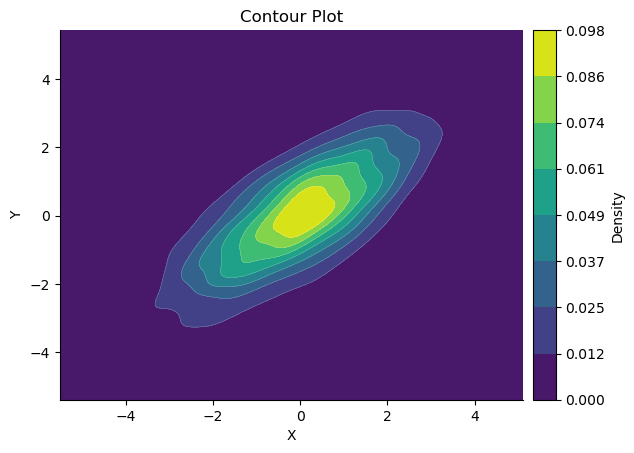

In [14]:
from symbulate import RV, Normal

sims = RV(Normal(0, 1.5) * Normal(0, 1)).sim(3000)  # joint RV: multiply the
# *distributions*, then wrap once in RV(...) -- two separate RV(...) objects
# don't share a probability space and can't be multiplied directly.
arr = np.asarray(sims.results)
sim_x, sim_y = arr[:, 0], 0.7 * arr[:, 0] + arr[:, 1]

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_density2D(sim_x, sim_y, ax, contour=True)
plt.show()

## Verification checklist

- [ ] Section 1's default plot (`contour=False`) is a smooth continuous gradient with no countable bands
- [ ] Section 1's `contour=True` plot shows exactly 8 discrete color values, countable against the colorbar segments
- [ ] `contour=True` differs from `contour=False` by the discrete bands and thin white band outlines
- [ ] `contour=True, levels=16` draws 16 bands on the same data; `contour=True, levels=1` raises the student-friendly ValueError
- [ ] Passing `levels=` without `contour=True` prints a UserWarning and is ignored (plot stays continuous)
- [ ] Both modes use viridis and label the colorbar "Density"
- [ ] In contour mode, colorbar tick labels are rounded (e.g. 0.012, not 0.01241), and stay distinct
- [ ] Colorbar sits on the right via `make_axes_locatable`
- [ ] Quantile-based x-range is visibly narrower than raw min/max on Exponential data
- [ ] A second call on the same axes prints the readability warning and still draws
- [ ] Works on real `.sim()` output, not just numpy arrays